#                                                       ML PROJECT

### 1 - INTRODUCTION

Description...............................

### 2 - IMPORTS

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

### 3 - LOADING DATASETS

In [42]:
# Loading them into dataframes for easy manipulations

fs1 = pd.read_csv("data/FS1.txt", sep="\t", header=None)
ps2 = pd.read_csv("data/PS2.txt", sep="\t", header=None)
profile = pd.read_csv("data/profile.txt", sep="\t", header=None)

# extraction 
valve_condition = profile.iloc[:,1]

In [43]:
fs1.head(5)

,0,1,2,3,4,5,6,7,8,9,...,590,591,592,593,594,595,596,597,598,599
0,8.990,0.770,0.641,0.006,0.000,0.000,0.001,0.003,0.001,0.001,...,7.743,7.992,7.919,7.773,7.955,7.823,7.963,7.876,7.738,8.036
1,8.919,0.815,0.709,0.009,0.004,0.000,0.001,0.000,0.000,0.001,...,7.831,8.003,7.923,7.745,7.867,7.747,7.969,7.969,7.963,7.890
2,9.179,0.683,0.528,0.008,0.003,0.001,0.003,0.003,0.004,0.006,...,7.862,7.815,7.894,7.743,7.936,7.770,7.982,7.873,7.898,7.952
3,9.034,0.728,0.595,0.009,0.001,0.004,0.003,0.003,0.003,0.001,...,7.631,7.949,7.773,8.054,7.827,8.011,7.919,7.938,7.877,7.773
4,8.729,0.705,0.446,0.014,0.007,0.003,0.001,0.003,0.001,0.000,...,7.771,7.936,7.919,7.946,7.804,7.983,7.838,7.882,7.894,7.825


In [44]:
ps2.head(5)

,0,1,2,3,4,5,6,7,8,9,...,5990,5991,5992,5993,5994,5995,5996,5997,5998,5999
0,125.50,125.39,125.40,125.03,124.05,123.18,104.01,56.500,23.992,18.406,...,125.02,125.00,125.10,125.09,124.98,124.91,124.98,125.11,125.14,125.10
1,125.06,125.08,125.09,124.69,123.84,123.14,103.63,63.687,28.359,21.711,...,124.80,124.88,125.13,125.22,125.09,124.98,125.06,125.13,125.09,125.04
2,125.13,125.27,125.23,124.74,123.94,123.23,106.35,60.516,26.258,19.258,...,124.61,124.69,124.74,124.71,124.59,124.64,124.74,124.73,124.77,124.88
3,124.93,124.96,124.92,124.41,123.60,122.88,103.99,58.859,27.781,21.469,...,124.82,124.79,124.69,124.69,124.77,124.83,124.69,124.53,124.51,124.59
4,124.72,124.74,124.66,124.31,123.57,122.74,105.94,62.648,30.875,23.883,...,124.80,124.67,124.49,124.56,124.69,124.62,124.45,124.41,124.47,124.51


In [45]:
print(valve_condition.shape)
valve_condition.head(5)

(2205,)


0    100
1    100
2    100
3    100
4    100
Name: 1, dtype: int64

### 4 - UNDERSTANDING THE DATA

In [46]:
print("FS1 shape:", fs1.shape)
print("PS2 shape:", ps2.shape)
print("Valve condition shape:", valve_condition.shape)

FS1 shape: (2205, 600)
PS2 shape: (2205, 6000)
Valve condition shape: (2205,)


In [47]:
print("Number of cycles in FS1:", len(fs1))
print("Number of cycles in PS2:", len(ps2))
print("Number of target values:", len(valve_condition))
print("\nSame number of cycles:",
      len(fs1) == len(ps2) == len(valve_condition))

Number of cycles in FS1: 2205
Number of cycles in PS2: 2205
Number of target values: 2205

Same number of cycles: True


Comme nos deux datasets contienent le meme nombre de cycle, on peut conclure que chaque cycle de PS2 doit correspondre a un cycle FS1 et a une valeur de valve_condition. Donc on peut concatener nos donnees sur les lignes.

In [48]:
print("FS1 data types:")
print(fs1.dtypes.value_counts())
print("\nPS2 data types:")
print(ps2.dtypes.value_counts())
print("\nValve condition type:")
print(valve_condition.dtype)

FS1 data types:
float64    600
Name: count, dtype: int64

PS2 data types:
float64    6000
Name: count, dtype: int64

Valve condition type:
int64


On conclu que les capteur sont bien numeriques

In [49]:
print("Valve condition unique values:")
print(np.sort(valve_condition.unique()))

Valve condition unique values:
[ 73  80  90 100]


Notre base de donnees contient 2205 cycles de functionnement. Chaque ligne represent un cycle de fonctionnement complet de notre system hydraulique.
- PS2.txt contient les donnees du cateur de Pression "PS2" en bar avec une frequence de 100 Hz dans la valve
- FS1.txt contient les donnees du capteur de debit volumique "FS1" en l/min avec une frequence de 10Hz dans la valve
- valve_condition contient les donnees des coditions de fonctionnement de la valve

### 5 - DESCRIPTIVE STATISTIQUES

In [50]:
fs1.describe()

,0,1,2,3,4,5,6,7,8,9,...,590,591,592,593,594,595,596,597,598,599
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000
mean,8.287100,0.857298,0.563584,0.031154,0.003567,0.002926,0.002683,0.002458,0.002436,0.002311,...,7.638567,7.638928,7.642123,7.641907,7.638804,7.643067,7.637415,7.645035,7.638999,7.637983
std,0.480969,0.125100,0.152903,0.039403,0.002810,0.002540,0.002501,0.002410,0.002451,0.002378,...,0.530204,0.529731,0.530209,0.530325,0.529648,0.530317,0.529648,0.530884,0.530817,0.529553
min,7.033000,0.522000,0.309000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.106000,1.117000,1.119000,1.123000,1.109000,1.111000,1.118000,1.120000,1.124000,1.120000
25%,7.961000,0.773000,0.445000,0.009000,0.001000,0.001000,0.000000,0.000000,0.000000,0.000000,...,7.514000,7.515000,7.518000,7.515000,7.519000,7.518000,7.513000,7.525000,7.510000,7.519000
50%,8.278000,0.855000,0.531000,0.016000,0.003000,0.003000,0.003000,0.001000,0.001000,0.001000,...,7.712000,7.709000,7.711000,7.714000,7.706000,7.714000,7.707000,7.713000,7.710000,7.708000
75%,8.610000,0.944000,0.656000,0.036000,0.005000,0.004000,0.004000,0.004000,0.004000,0.004000,...,7.815000,7.815000,7.818000,7.823000,7.813000,7.820000,7.813000,7.821000,7.826000,7.815000
max,11.754000,1.488000,0.985000,0.298000,0.015000,0.013000,0.011000,0.011000,0.012000,0.012000,...,8.060000,8.078000,8.072000,8.064000,8.073000,8.080000,8.076000,8.083000,8.078000,8.087000


In [51]:
ps2.describe()

,0,1,2,3,4,5,6,7,8,9,...,5990,5991,5992,5993,5994,5995,5996,5997,5998,5999
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000
mean,123.362422,123.364358,123.339202,122.831868,121.808503,120.693455,104.294819,64.491438,35.220531,27.355589,...,123.359583,123.356580,123.355896,123.360023,123.361705,123.358848,123.358966,123.364444,123.364957,123.361741
std,3.701729,3.694412,3.700527,3.819922,3.746546,3.541433,9.616892,8.636717,3.792106,3.286553,...,3.701453,3.705096,3.702194,3.701239,3.698299,3.694301,3.700553,3.703952,3.700664,3.703531
min,119.610000,119.630000,118.920000,118.650000,115.830000,97.289000,27.031000,0.977000,1.133000,1.203000,...,119.140000,119.630000,119.680000,119.590000,119.690000,119.520000,119.650000,119.650000,119.600000,119.520000
25%,121.630000,121.670000,121.660000,120.560000,118.830000,117.690000,96.664000,58.883000,33.398000,25.523000,...,121.630000,121.650000,121.670000,121.660000,121.660000,121.670000,121.670000,121.650000,121.630000,121.630000
50%,123.040000,123.040000,123.010000,122.620000,122.060000,121.520000,105.080000,64.773000,35.180000,27.398000,...,123.040000,123.040000,123.060000,123.030000,123.030000,123.030000,123.020000,123.020000,123.020000,123.040000
75%,125.100000,125.100000,125.090000,124.830000,124.480000,124.270000,113.020000,71.297000,37.289000,29.266000,...,125.100000,125.120000,125.110000,125.120000,125.110000,125.090000,125.100000,125.110000,125.130000,125.110000
max,165.480000,165.260000,165.530000,165.690000,160.570000,125.220000,117.390000,79.102000,44.617000,35.398000,...,165.570000,165.730000,165.560000,165.350000,165.440000,165.430000,165.440000,165.630000,165.360000,165.340000


Nous procedons ensuite par analyser valve condition

In [52]:
valve_condition.value_counts().sort_index()

1
73      360
80      360
90      360
100    1125
Name: count, dtype: int64

In [53]:
valve_distribution = pd.DataFrame({
    "Count": valve_condition.value_counts().sort_index(),
    "Percentage": valve_condition.value_counts(normalize=True)
                                  .sort_index()
                                  .mul(100)
                                  .round(2)
})

valve_distribution

,Count,Percentage
1,,
73,360,16.33
80,360,16.33
90,360,16.33
100,1125,51.02


In [54]:
# Sensor summary for all the data in the dataset
sensor_summary = pd.DataFrame({
    "PS2": pd.Series(ps2.to_numpy().ravel()).describe(),
    "FS1": pd.Series(fs1.to_numpy().ravel()).describe()
})
sensor_summary

,PS2,FS1
count,1.323000e+07,1.323000e+06
mean,1.093799e+02,6.198549e+00
std,4.810317e+01,3.213827e+00
min,0.000000e+00,0.000000e+00
25%,1.185400e+02,7.339000e+00
50%,1.257000e+02,7.641000e+00
75%,1.304100e+02,7.796000e+00
max,1.677700e+02,2.047900e+01


### 6 - MISSING VALUES & OUTLIER ANALYSIS

Verification des valeurs manquantes

In [55]:
missing_values = pd.DataFrame({
    "Dataset": ["PS2", "FS1", "Valve Condition"],
    "Missing Values": [
        ps2.isna().sum().sum(),
        fs1.isna().sum().sum(),
        valve_condition.isna().sum()
    ]
})
missing_values

,Dataset,Missing Values
0,PS2,0
1,FS1,0
2,Valve Condition,0


Nous constatons que nous n'avons pas de valeur manquantes dans notre base de donnees. Donc, nous pouvons proceder a la verification des outliers et des valeurs aberrantes.

In [56]:
print("Infinite values in PS2:",
      np.isinf(ps2.to_numpy()).sum())

print("Infinite values in FS1:",
      np.isinf(fs1.to_numpy()).sum())

Infinite values in PS2: 0
Infinite values in FS1: 0


In [57]:
print("Duplicate PS2 cycles:", ps2.duplicated().sum())
print("Duplicate FS1 cycles:", fs1.duplicated().sum())

Duplicate PS2 cycles: 0
Duplicate FS1 cycles: 0


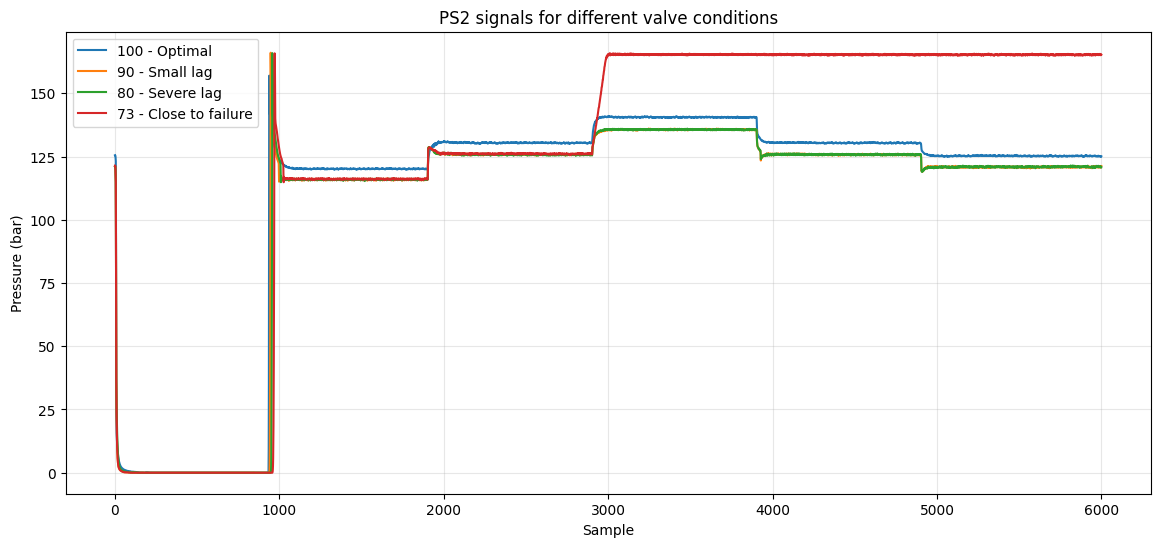

In [58]:
# Coourbe de la pression pour les 5 premier cycles pour visualiser les donnees
# Valve conditions
conditions = [100, 90, 80, 73]
condition_labels = { 100: "Optimal", 90: "Small lag", 80: "Severe lag", 73: "Close to failure"}
plt.figure(figsize=(14, 6))
for condition in conditions:
    cycle_index = valve_condition[
        valve_condition == condition].index[0]
    plt.plot(
        ps2.iloc[cycle_index],
        label=f"{condition} - {condition_labels[condition]}")
plt.title("PS2 signals for different valve conditions")
plt.xlabel("Sample")
plt.ylabel("Pressure (bar)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

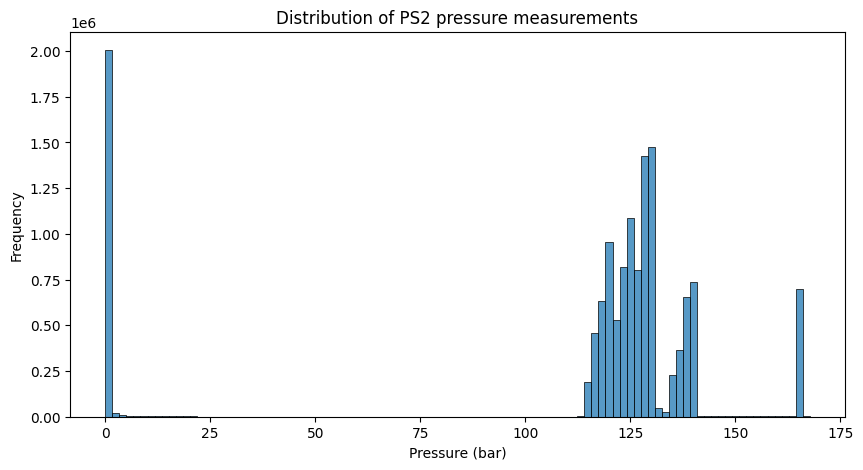

In [59]:
# Distribution des donnees de pressions du capteur PS2
plt.figure(figsize=(10, 5))
sns.histplot(
    ps2.to_numpy().ravel(),
    bins=100
)
plt.title("Distribution of PS2 pressure measurements")
plt.xlabel("Pressure (bar)")
plt.ylabel("Frequency")
plt.show()

On constate que nous avons une distribution assez irregulier. Nous avons un pic de valeur proche de 0 et une distribution de donnees entre 100 - 175.
Cette distribution de donnnees et du aux fonctions mechanique de notre valve. Nous avons des cycles de chargement et de dechargement qui font fluctuer les valeur de pressions de la valve.
Nous avons aucune valuer negative ni aucun outlier ce qui confirme que notre dataset PS2 est conform

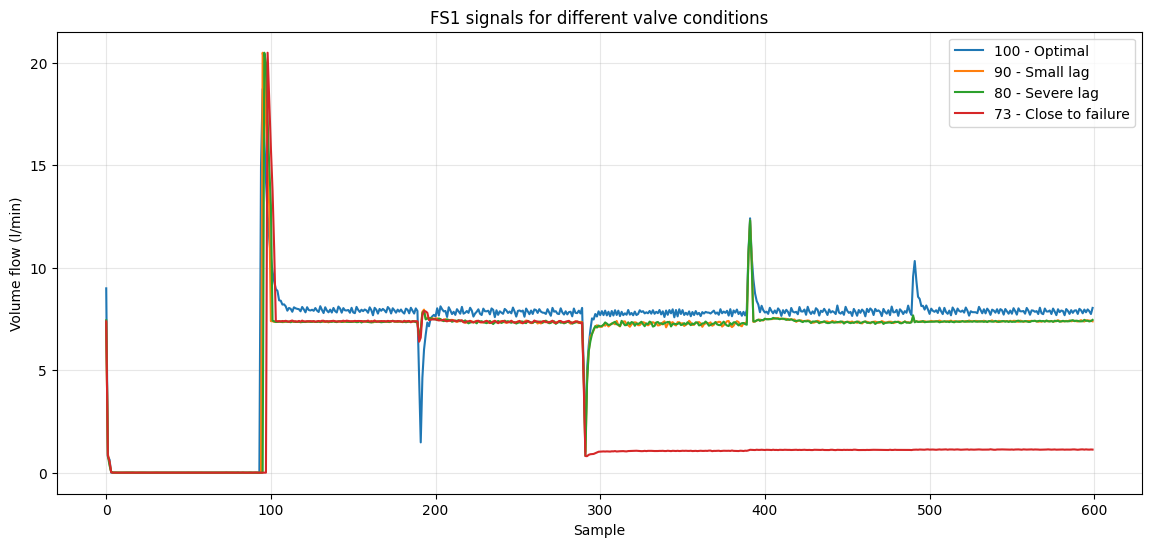

In [60]:
# Coourbe du debit volumique pour le premier cycle pour visualiser les donnees
plt.figure(figsize=(14, 6))
for condition in conditions:
    cycle_index = valve_condition[
        valve_condition == condition].index[0]
    plt.plot(
        fs1.iloc[cycle_index],
        label=f"{condition} - {condition_labels[condition]}")
plt.title("FS1 signals for different valve conditions")
plt.xlabel("Sample")
plt.ylabel("Volume flow (l/min)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

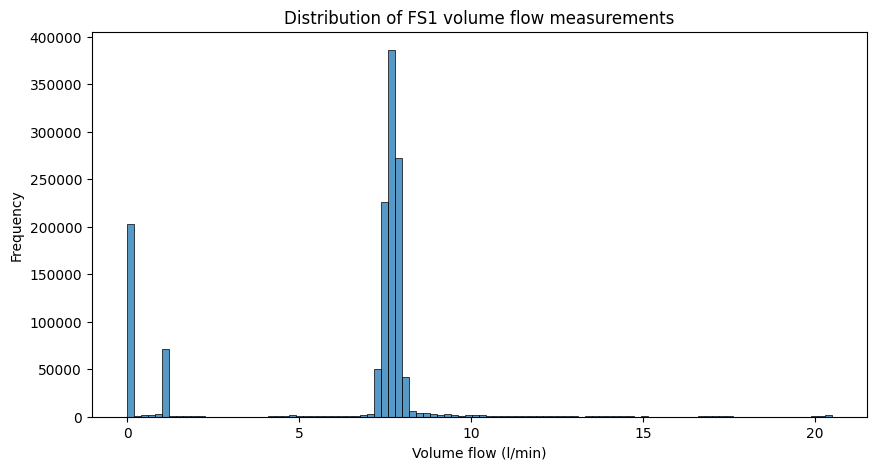

In [61]:
# Distribution des donnees du debit volumique
plt.figure(figsize=(10, 5))
sns.histplot(
    fs1.to_numpy().ravel(),
    bins=100
)
plt.title("Distribution of FS1 volume flow measurements")
plt.xlabel("Volume flow (l/min)")
plt.ylabel("Frequency")
plt.show()

Commen les ces donnees representent un systeme mechanique qui opere avec des differentes phase durant un cycle(chargement et dechargement), les distributions ne suivent pas une loi normale.
Ainsi, les valuers extremes observe sont conserve et sont pas consideres comme des outliers car elles decrivent les systeme.

### 7 - FEATURE ENGINEERING

Grace a la documentation, nous comprenons que les donnees sont formatees d'une facon non conventionnnelle. Le donnees sont enregistré par cycle et enregiste sur une meme ligne avec une frequence d'echantillonage. Donc une ligne representre les donnees enregistre pour un cycle complet. 

Pour un cycle complet, on a : 
- Pression (PS2) avec pour frequence 100 Hz: 60 seconds * 100 mesures/seconds = 6000 mesures.
- Debit volumique (FS1) avec pour frequence 10 Hz: 60 seconds * 10 mesures/seconds = 600 mesures
Ca correspond exactement aux nombre de colonnes de nos dataset respectives

Donc nous devons proceder aux traitement des donnees pour rendre les donnees exploitable. Car, on veut resumer chaqye signal par des caracteristiques capables de communiquer toutes les informations : 
-Son niveau général 
-Sa dispersion 
-Ses valeurs extrêmes 
-Sa forme de distribution 
-Sa variation pendant le cycle.

Pour chaque capteur et pour chaque cycle de 60 secondes, on resume toute la série temporelle par 5 statistiques :
- moyenne (mean)
- écart-type (std)
- minimum (min)
- maximum (max)
- médiane (median)
- Range
Donc au lieu de garder les milliers de valeurs brutes d’un cycle, on transforme chaque cycle en quelques variables résumées. Car ces nouveaux feautures porte plus d'information.

In [82]:
# Implementation d'une fonction qui permet de generer des features telles que la moyenne,ecart-type,min, max etc. 
from scipy.signal import find_peaks

def extract_features(df, prefix, sampling_rate):
    features = pd.DataFrame(index=df.index)
    # Basic statistical features
    features[f"{prefix}_mean"] = df.mean(axis=1)
    features[f"{prefix}_median"] = df.median(axis=1)
    features[f"{prefix}_std"] = df.std(axis=1)
    features[f"{prefix}_min"] = df.min(axis=1)
    features[f"{prefix}_max"] = df.max(axis=1)
    features[f"{prefix}_range"] = (
        features[f"{prefix}_max"]
        - features[f"{prefix}_min"])
    features[f"{prefix}_mean_abs_change"] = (
        df.diff(axis=1)
          .abs()
          .mean(axis=1))
    # Advanced features
    energy = []
    entropy_values = []
    dominant_frequencies = []
    peak_counts = []
    rolling_mean_std = []
    rolling_std_max = []
    window_size = sampling_rate
    for _, row in df.iterrows():
        signal = row.to_numpy()
        # Signal energy
        energy.append(
            np.mean(signal ** 2)
        )
        # FFT
        centered_signal = signal - np.mean(signal)
        fft_values = np.fft.rfft(centered_signal)
        power = np.abs(fft_values) ** 2
        frequencies = np.fft.rfftfreq(
            len(signal),
            d=1 / sampling_rate
        )
        # Ignore frequency = 0
        power = power[1:]
        frequencies = frequencies[1:]
        # Dominant frequency
        dominant_frequencies.append(
            frequencies[np.argmax(power)]
        )
        # Spectral entropy
        probability = power / (
            power.sum() + 1e-12
        )
        entropy = -np.sum(
            probability *
            np.log2(probability + 1e-12)
        )
        entropy = entropy / np.log2(
            len(probability)
        )
        entropy_values.append(entropy)
        # Peak detection
        peaks, _ = find_peaks(
            signal,
            prominence=0.5 * np.std(signal)
        )
        peak_counts.append(len(peaks))
        # Rolling window features
        signal_series = pd.Series(signal)

        rolling_mean = signal_series.rolling(
            window=window_size
        ).mean()
        rolling_std = signal_series.rolling(
            window=window_size
        ).std()
        rolling_mean_std.append(
            rolling_mean.std()
        )
        rolling_std_max.append(
            rolling_std.max()
        )
    features[f"{prefix}_energy"] = energy
    features[f"{prefix}_spectral_entropy"] = entropy_values
    features[f"{prefix}_dominant_frequency"] = dominant_frequencies
    features[f"{prefix}_peak_count"] = peak_counts
    features[f"{prefix}_rolling_mean_std"] = rolling_mean_std
    features[f"{prefix}_rolling_std_max"] = rolling_std_max

    return features

In [63]:
ps2_features = extract_features(
    ps2,
    prefix="PS2",
    sampling_rate=100)
fs1_features = extract_features(
    fs1,
    prefix="FS1",
    sampling_rate=10)
print("PS2 features shape:", ps2_features.shape)
print("FS1 features shape:", fs1_features.shape)

PS2 features shape: (2205, 13)
FS1 features shape: (2205, 13)


In [64]:
X = pd.concat(
    [ps2_features, fs1_features],
    axis=1)
X.head()

,PS2_mean,PS2_median,PS2_std,PS2_min,PS2_max,PS2_range,PS2_mean_abs_change,PS2_energy,PS2_spectral_entropy,PS2_dominant_frequency,...,FS1_min,FS1_max,FS1_range,FS1_mean_abs_change,FS1_energy,FS1_spectral_entropy,FS1_dominant_frequency,FS1_peak_count,FS1_rolling_mean_std,FS1_rolling_std_max
0,109.466914,129.365,47.114508,0.0,156.99,156.99,0.117134,14202.412025,0.237172,0.016667,...,0.0,18.710,18.710,0.256631,54.099268,0.467683,0.016667,4,2.827221,8.367210
1,109.354890,129.385,47.045611,0.0,157.56,157.56,0.120195,14171.412675,0.237185,0.016667,...,0.0,18.712,18.712,0.247778,54.117921,0.457191,0.016667,4,2.830642,7.959359
2,109.158845,129.325,46.992060,0.0,156.97,156.97,0.123362,14123.539055,0.237149,0.016667,...,0.0,18.698,18.698,0.251705,54.209083,0.462013,0.016667,4,2.832054,8.099865
3,109.064807,128.865,46.972221,0.0,156.44,156.44,0.125399,14101.154022,0.237032,0.016667,...,0.0,18.896,18.896,0.249077,54.272252,0.466355,0.016667,4,2.832145,8.299677
4,108.931434,129.000,46.874946,0.0,158.13,158.13,0.127465,14062.951759,0.236902,0.016667,...,0.0,18.876,18.876,0.249613,53.814545,0.460357,0.016667,4,2.827509,8.058890


In [65]:
# Verifier si les donnees ont ete bien generé
print("Missing values in engineered features:")
print(X.isna().sum().sum())
print("\nInfinite values:")
print(np.isinf(X.to_numpy()).sum())
print("\nDuplicated feature rows:")
print(X.duplicated().sum())

Missing values in engineered features:
0

Infinite values:
0

Duplicated feature rows:
0


# Verification de la variance des features, pour identier des features constats qui n'apporte aucune information a notre base de donnees

In [66]:
feature_variance = X.var()
constant_features = feature_variance[
    feature_variance == 0
]
constant_features

PS2_min                   0.0
PS2_dominant_frequency    0.0
dtype: float64

In [67]:
X = X.drop(columns=constant_features.index)

PS2_min et PS2_dominant_frequency avait une variance nulle, donc elle avait une valeur constante pour chaque cycle. Donc la variable napportait aucune information a notre modele.

In [68]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
PS2_mean,2205.0,1.093799e+02,4.986585,104.406307,106.962382,107.730169,109.421612,131.589089
PS2_median,2205.0,1.286777e+02,3.469525,124.445000,127.215000,127.965000,129.950000,165.400000
PS2_std,2205.0,4.773616e+01,3.271949,45.206954,46.209665,46.805986,47.207567,59.553248
PS2_max,2205.0,1.665205e+02,0.977997,155.040000,166.180000,166.650000,167.100000,167.770000
PS2_range,2205.0,1.665205e+02,0.977997,155.040000,166.180000,166.650000,167.100000,167.770000
PS2_mean_abs_change,2205.0,1.389516e-01,0.029491,0.112485,0.119150,0.130835,0.149416,0.742438
PS2_energy,2205.0,1.427788e+04,1482.552012,12996.973114,13600.565833,13768.195898,14206.139026,20793.922677
PS2_spectral_entropy,2205.0,2.318849e-01,0.018403,0.175172,0.236300,0.238436,0.239046,0.241959
PS2_peak_count,2205.0,1.133787e+00,0.408359,1.000000,1.000000,1.000000,1.000000,4.000000
PS2_rolling_mean_std,2205.0,4.671452e+01,3.306400,44.206108,45.176622,45.785539,46.145379,58.555433


### Creation du target (binaire)

Comme notre tache concerne une classification binaire, nous devons standardiser les donnees de valve condition pour avoir deux classe pour notre classification.
D'apres notre documentation, on a :
100 = functionnement optimal. Donc on lui attribue la classe 0
et different de 100 = functionnement non-optimale. Donc on lui attribue la classe de 1

In [69]:
y = (valve_condition != 100).astype(int)
y.value_counts().sort_index()

1
0    1125
1    1080
Name: count, dtype: int64

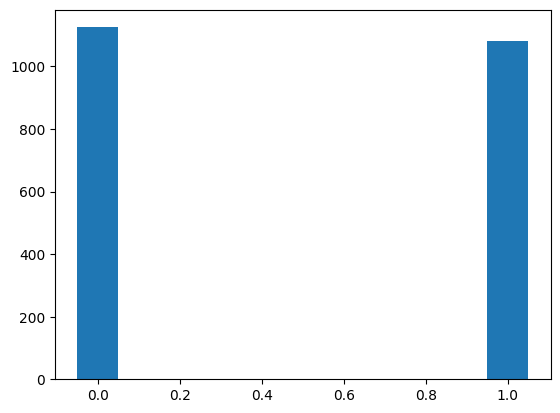

In [70]:
# Distribution of the target variables in our dataset
from collections import Counter
histogram = Counter(y)
plt.bar(histogram.keys(), histogram.values(),0.1)
plt.show()


In [71]:
target_distribution = pd.DataFrame({
    "Count": y.value_counts().sort_index(),
    "Percentage": (
        y.value_counts(normalize=True)
         .sort_index()
         .mul(100)
         .round(2)
    )
})
target_distribution.index = ["Optimal (0)", "Non-optimal (1)"]
target_distribution

,Count,Percentage
Optimal (0),1125,51.02
Non-optimal (1),1080,48.98


Nous constatons que les classes sont assez equilibre dans notre dataset. Ceci nous garantit que d'avoir des classes equilibres lors de l'entrainement de notre modele

### 7 - SEPARATION DES DONNEES SELON L'ENONCE

Comme specifie durant l'enonce de notre projet, nous alons utliser les 2000 premiers ligne pour entrainer notre modele et le reste pour la validation et pour obtenir nos donnees de test et de validation.

In [72]:
X_train = X.iloc[:2000].copy()
X_test = X.iloc[2000:].copy()
y_train = y.iloc[:2000].copy()
y_test = y.iloc[2000:].copy()
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2000, 24)
X_test shape: (205, 24)
y_train shape: (2000,)
y_test shape: (205,)


### 7 - VERIFICATION DE LEQUILIBRE DES CLASSE DANS NOS DONNEES D'ENTRAINEMENT

In [73]:
train_distribution = pd.DataFrame({
    "Count": y_train.value_counts().sort_index(),
    "Percentage": (
        y_train.value_counts(normalize=True)
               .sort_index()
               .mul(100)
               .round(2)
    )
})
train_distribution.index = ["Optimal (0)", "Non-optimal (1)"]
train_distribution

,Count,Percentage
Optimal (0),1052,52.6
Non-optimal (1),948,47.4


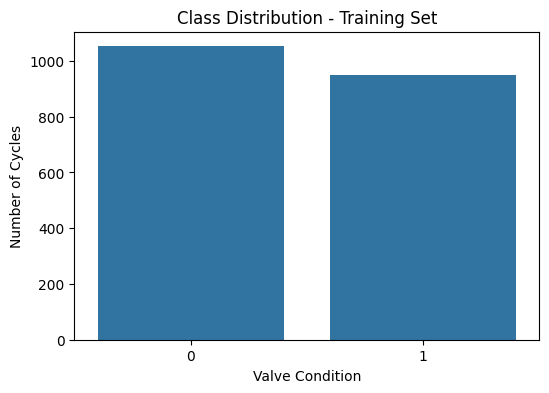

In [74]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title("Class Distribution - Training Set")
plt.xlabel("Valve Condition")
plt.ylabel("Number of Cycles")
plt.show()

Nous avons une repartition des donnees d'entrainement assez equilibre dans notre base de donnees avec des pourcentages tres proche de 50%

In [75]:
X_train = X_train.drop(columns=["PS2_range","FS1_min","FS1_range"])
X_test = X_test.drop(columns=["PS2_range","FS1_min","FS1_range"])

Nous avons supprime la colonne PS2_rannge car si PS2_min est nulle, alors PS2_range = PS2_max. Donc PS2_range n'apporte aucune information.
De meme FS1_min a des valuer sensiblement proche de 0, donc FS1 range et FS1_max ont une correlation lineaire tres forte. Donc, on supprime aussi FS1_min et FS1_range.

In [76]:
X_train

,PS2_mean,PS2_median,PS2_std,PS2_max,PS2_mean_abs_change,PS2_energy,PS2_spectral_entropy,PS2_peak_count,PS2_rolling_mean_std,PS2_rolling_std_max,...,FS1_median,FS1_std,FS1_max,FS1_mean_abs_change,FS1_energy,FS1_spectral_entropy,FS1_dominant_frequency,FS1_peak_count,FS1_rolling_mean_std,FS1_rolling_std_max
0,109.466914,129.365,47.114508,156.99,0.117134,14202.412025,0.237172,1,46.091326,66.787601,...,7.8360,3.015428,18.710,0.256631,54.099268,0.467683,0.016667,4,2.827221,8.367210
1,109.354890,129.385,47.045611,157.56,0.120195,14171.412675,0.237185,1,46.032664,66.816002,...,7.8530,3.006248,18.712,0.247778,54.117921,0.457191,0.016667,4,2.830642,7.959359
2,109.158845,129.325,46.992060,156.97,0.123362,14123.539055,0.237149,1,45.974528,66.478269,...,7.8470,3.014248,18.698,0.251705,54.209083,0.462013,0.016667,4,2.832054,8.099865
3,109.064807,128.865,46.972221,156.44,0.125399,14101.154022,0.237032,1,45.952228,66.371053,...,7.8430,3.020176,18.896,0.249077,54.272252,0.466355,0.016667,4,2.832145,8.299677
4,108.931434,129.000,46.874946,158.13,0.127465,14062.951759,0.236902,1,45.871736,66.389376,...,7.8310,3.011550,18.876,0.249613,53.814545,0.460357,0.016667,4,2.827509,8.058890
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,108.937855,129.570,47.361077,166.97,0.116737,14110.153939,0.237479,1,46.331392,68.739616,...,7.5895,2.975988,19.130,0.249967,51.091072,0.478350,0.016667,4,2.771406,8.899924
1996,108.906355,129.630,47.367681,167.08,0.118568,14103.917454,0.238126,1,46.320032,69.295841,...,7.6065,2.956631,19.629,0.249509,50.921560,0.465012,0.016667,4,2.771060,8.416693
1997,108.948123,129.655,47.374170,167.12,0.117574,14113.631446,0.238513,1,46.318929,69.928265,...,7.5955,2.949933,19.958,0.253943,50.763582,0.460835,0.016667,4,2.769563,8.214285
1998,108.924002,129.465,47.356936,167.09,0.117026,14106.743860,0.237424,1,46.328704,68.723170,...,7.5955,2.973138,19.219,0.243270,51.015366,0.476092,0.016667,4,2.770666,8.840175


### JOYCE PART

In [77]:

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [78]:
# fonction pour entrainer le modele de regression logistique
def train_logistic_regression(X_train,X_test, y_train, y_test):
    
    #normaliser
    norm=StandardScaler()
    X_train=norm.fit_transform(X_train)
    
    #entrainer le modele
    model=LogisticRegression()
    model.fit(X_train,y_train)
    
    #prediction
    y_pred=model.predict(X_test)
    
    # Affichage des métriques
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    return model
model=train_logistic_regression(X_train,X_test,y_train,y_test)

Confusion Matrix:
[[ 73   0]
 [132   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.36      1.00      0.53        73
           1       0.00      0.00      0.00       132

    accuracy                           0.36       205
   macro avg       0.18      0.50      0.26       205
weighted avg       0.13      0.36      0.19       205

Accuracy: 0.35609756097560974


c:\Users\koudj_wkfw7eh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\koudj_wkfw7eh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\koudj_wkfw7eh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\koudj_wkfw7eh\AppData\Local\Python\pythoncore

In [80]:
# fonction pour entrainer SVM
def train_svm(X_train,X_test, y_train, y_test):
  

    #normaliser
    norm=StandardScaler()
    X_train=norm.fit_transform(X_train)

    
    #entrainer le modele
    model=SVC(kernel="rbf", probability=True)
    model.fit(X_train,y_train)
    
    #prediction
    y_pred=model.predict(X_test)
    
    # Affichage des métriques
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    return model
model=train_svm(X_train,X_test, y_train, y_test)


Confusion Matrix:
[[  0  73]
 [  0 132]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        73
           1       0.64      1.00      0.78       132

    accuracy                           0.64       205
   macro avg       0.32      0.50      0.39       205
weighted avg       0.41      0.64      0.50       205

Accuracy: 0.6439024390243903


c:\Users\koudj_wkfw7eh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
c:\Users\koudj_wkfw7eh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\koudj_wkfw7eh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\koudj_wkfw7eh\AppData\Local\Python\pythoncore-3.14-64\Lib\si